In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU , Input

In [35]:
df = pd.read_csv('/content/DJIA_indices_data.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)
df.set_index('Date', inplace=True)


df.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2006-12-29,12500.480469,12526.030273,12451.129883,12463.150391,161560000,12463.150391
2007-01-03,12459.540039,12580.349609,12404.820312,12474.519531,327200000,12474.519531
2007-01-04,12473.160156,12510.410156,12403.860352,12480.690430,259060000,12480.690430
2007-01-05,12480.049805,12480.129883,12365.410156,12398.009766,235220000,12398.009766
2007-01-08,12392.009766,12445.919922,12337.370117,12423.490234,223500000,12423.490234


In [36]:
print(f"Shape      : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
print(f"Nulls      :\n{df.isnull().sum()}")

Shape      : (2519, 6)
Columns    : ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
Nulls      :
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64


In [37]:
print(f"Date range : {df.index[0].date()}  →  {df.index[-1].date()}")

Date range : 2006-12-29  →  2016-12-30


In [38]:
df[['Open','High','Low','Close','Volume']].describe()

,Open,High,Low,Close,Volume
count,2519.000000,2519.000000,2519.000000,2519.000000,2.519000e+03
mean,13616.027058,13697.496397,13530.562851,13619.377627,1.753549e+08
std,3043.005262,3035.601279,3051.760730,3044.485660,9.652075e+07
min,6547.009766,6709.609863,6469.950195,6547.049805,8.410000e+06
25%,11410.520019,11484.924805,11317.035156,11411.595215,1.025800e+08
50%,13092.280273,13162.639648,13022.339844,13096.169922,1.492500e+08
75%,16458.660156,16528.945312,16377.850098,16459.155274,2.222200e+08
max,19968.970703,19987.630859,19941.960938,19974.619141,6.749200e+08


In [39]:
FEATURES    = ['Open', 'Close']
TARGET_COL  = 1
LOOKBACK    = 1
TRAIN_RATIO = 0.80

data   = df[FEATURES].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(data)

print(f"Raw data   : {data.shape}")
print(f"Scaled     : {scaled.shape}  |  min={scaled.min():.3f}  max={scaled.max():.3f}")

Raw data   : (2519, 2)
Scaled     : (2519, 2)  |  min=0.000  max=1.000


In [40]:
scaled

array([[0.44356192, 0.44059356],
       [0.44051166, 0.44144026],
       [0.44152642, 0.44189983],
       ...,
       [0.9996528 , 0.98950373],
       [0.99005289, 0.98846851],
       [0.9898822 , 0.98421013]])

### 3.2 Create Sequences

In [41]:
def create_sequences(data, lookback=1):
    """
    Slide a window of `lookback` rows over the scaled data.
    X : (n_samples, lookback, n_features)
    y : (n_samples, 1)  — next-day scaled Close
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback : i])
        y.append(data[i, TARGET_COL])

    return np.array(X), np.array(y)

In [92]:
X

array([[[0.44356192, 0.44059356]],

       [[0.44051166, 0.44144026]],

       [[0.44152642, 0.44189983]],

       ...,

       [[0.9980994 , 0.99779706]],

       [[0.9996528 , 0.98950373]],

       [[0.99005289, 0.98846851]]])

In [42]:
X, y = create_sequences(scaled)

In [43]:
split      = int(len(X) * TRAIN_RATIO)
X_train    = X[:split];   y_train    = y[:split]
X_test     = X[split:];   y_test     = y[split:]
dates_test = df.index[split + LOOKBACK:]

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"Train period : {df.index[LOOKBACK].date()}  →  {df.index[split-1].date()}")
print(f"Test  period : {dates_test[0].date()}  →  {dates_test[-1].date()}")

X_train : (2014, 1, 2)   y_train : (2014,)
X_test  : (504, 1, 2)    y_test  : (504,)
Train period : 2007-01-03  →  2014-12-30
Test  period : 2015-01-02  →  2016-12-30


## 4. Load Pre-Trained LSTM Model

In [44]:

model_GRU = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Use X_train.shape[2] for features
    GRU(128, return_sequences=True,),

    GRU(128, return_sequences=False),

    Dense(32, activation='relu'),
    Dense(1)
], name='GRU')

model_GRU.compile(optimizer='adam', loss='mean_squared_error')


model_GRU.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 1, 128)         │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,921 (601.25 KB)

 Trainable params: 153,921 (601.25 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:


history_GRU = model_GRU.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0399 - val_loss: 0.0117
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.4663e-04 - val_loss: 2.2841e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3583e-04 - val_loss: 3.5811e-04
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3429e-04 - val_loss: 1.7492e-04
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2921e-04 - val_loss: 1.9287e-04
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3184e-04 - val_loss: 1.5842e-04
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2815e-04 - val_loss: 1.8842e-04
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2833e-04 - val_loss: 2.0108e-04
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2880e-04 - val_loss: 3.1455e-04
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2987e-04 - val_loss: 1.9169e-04
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.4166e-04 - val_loss: 1.9

## 6. Prediction on Test Set

In [66]:
y_pred_scaled1 = model_GRU.predict(X_test, verbose=0)

def inverse_close(scaled_col, scaler, n_features=4, close_idx=3):
    dummy = np.zeros((len(scaled_col), n_features))
    dummy[:, close_idx] = scaled_col.ravel()
    return scaler.inverse_transform(dummy)[:, close_idx]


In [67]:
y_pred1 = inverse_close(y_pred_scaled1, scaler, n_features=len(FEATURES), close_idx=TARGET_COL)
y_test_actual = inverse_close(y_test,        scaler, n_features=len(FEATURES), close_idx=TARGET_COL)


In [68]:
print(f"Test samples   : {len(y_test_actual)}")
print(f"Actual  range  : ${y_test_actual.min():,.2f}  –  ${y_test_actual.max():,.2f}")
print(f"Pred    range  : ${y_pred1.min():,.2f}  –  ${y_pred1.max():,.2f}")

Test samples   : 504
Actual  range  : $15,660.18  –  $19,974.62
Pred    range  : $15,909.74  –  $20,184.94


In [97]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred1))
r2   = 1 - (np.sum((y_test_actual - y_pred1)**2) /
            np.sum((y_test_actual - np.mean(y_test_actual))**2))

print("═" * 40)
print(f"  RMSE  : {rmse:>12,.4f}")
print(f"  R²    : {r2:>12,.6f}")
print("═" * 40)

════════════════════════════════════════
  RMSE  :     251.5794
  R²    :     0.898694
════════════════════════════════════════


In [89]:
print(f"First Actual Value:   {y_test_actual[0]:,.2f}")
print(f"First Predicted Value: {y_pred1[0]:,.2f}")

First Actual Value:   17,832.99
First Predicted Value: 18,087.54


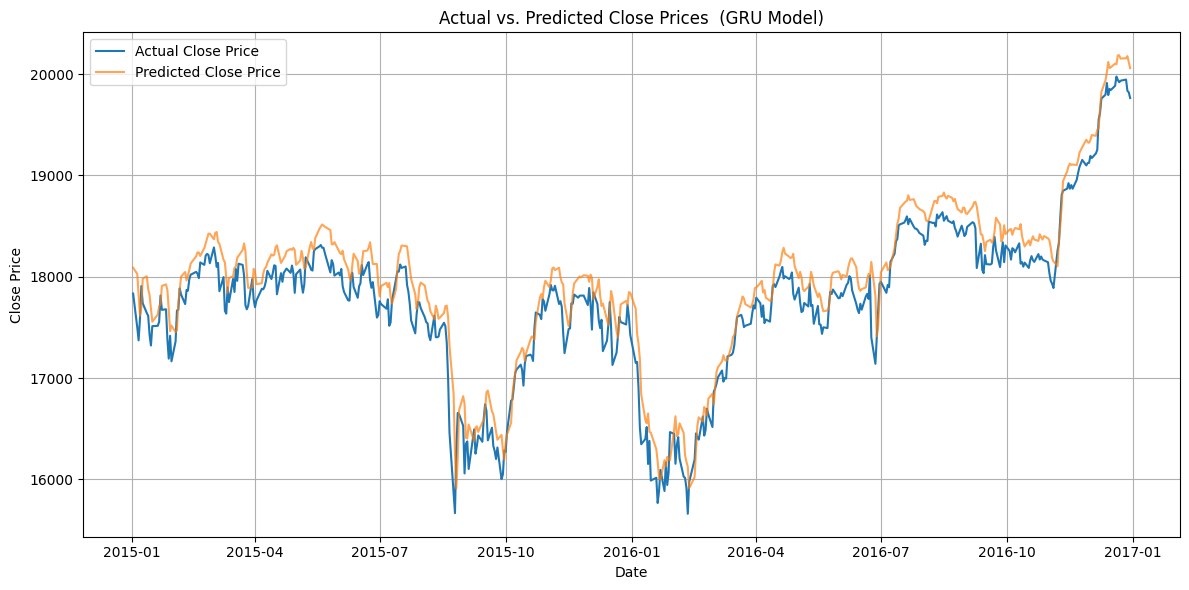

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_actual, label='Actual Close Price')
plt.plot(dates_test, y_pred1, label='Predicted Close Price', alpha=0.7)
plt.title('Actual vs. Predicted Close Prices  (GRU Model)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

BI

In [50]:

model_BI = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Use X_train.shape[2] for features
    GRU(128, return_sequences=True,),

    GRU(128, return_sequences=False),

    Dense(32, activation='relu'),
    Dense(1)
], name='GRU')

model_BI.compile(optimizer='adam', loss='mean_squared_error')


model_BI.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 1, 128)         │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,921 (601.25 KB)

 Trainable params: 153,921 (601.25 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:


history_BI = model_BI.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0384 - val_loss: 0.0116
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.7381e-04 - val_loss: 2.0398e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.3243e-04 - val_loss: 1.6344e-04
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2616e-04 - val_loss: 1.7022e-04
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2726e-04 - val_loss: 1.8005e-04
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2929e-04 - val_loss: 1.6108e-04
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2906e-04 - val_loss: 1.6154e-04
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2385e-04 - val_loss: 1.6260e-04
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2632e-04 - val_loss: 2.2290e-04
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2500e-04 - val_loss: 1.5886e-04
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2219e-04 - val_loss: 1.

In [73]:
y_pred_scaled2 = model_BI.predict(X_test, verbose=0)

def inverse_close(scaled_col, scaler, n_features=4, close_idx=3):
    dummy = np.zeros((len(scaled_col), n_features))
    dummy[:, close_idx] = scaled_col.ravel()
    return scaler.inverse_transform(dummy)[:, close_idx]


In [74]:
y_pred2 = inverse_close(y_pred_scaled2, scaler, n_features=len(FEATURES), close_idx=TARGET_COL)
y_test_actual = inverse_close(y_test,        scaler, n_features=len(FEATURES), close_idx=TARGET_COL)


In [75]:
print(f"Test samples   : {len(y_test_actual)}")
print(f"Actual  range  : ${y_test_actual.min():,.2f}  –  ${y_test_actual.max():,.2f}")
print(f"Pred    range  : ${y_pred2.min():,.2f}  –  ${y_pred2.max():,.2f}")

Test samples   : 504
Actual  range  : $15,660.18  –  $19,974.62
Pred    range  : $15,779.31  –  $20,076.11


In [98]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred2))
r2   = 1 - (np.sum((y_test_actual - y_pred2)**2) /
            np.sum((y_test_actual - np.mean(y_test_actual))**2))

print("═" * 40)
print(f"  RMSE  : {rmse:>12,.4f}")
print(f"  R²    : {r2:>12,.6f}")
print("═" * 40)

════════════════════════════════════════
  RMSE  :     171.6837
  R²    :     0.952822
════════════════════════════════════════


In [88]:
print(f"First Actual Value:   {y_test_actual[0]:,.2f}")
print(f"First Predicted Value: {y_pred2[0]:,.2f}")

First Actual Value:   17,832.99
First Predicted Value: 17,948.23


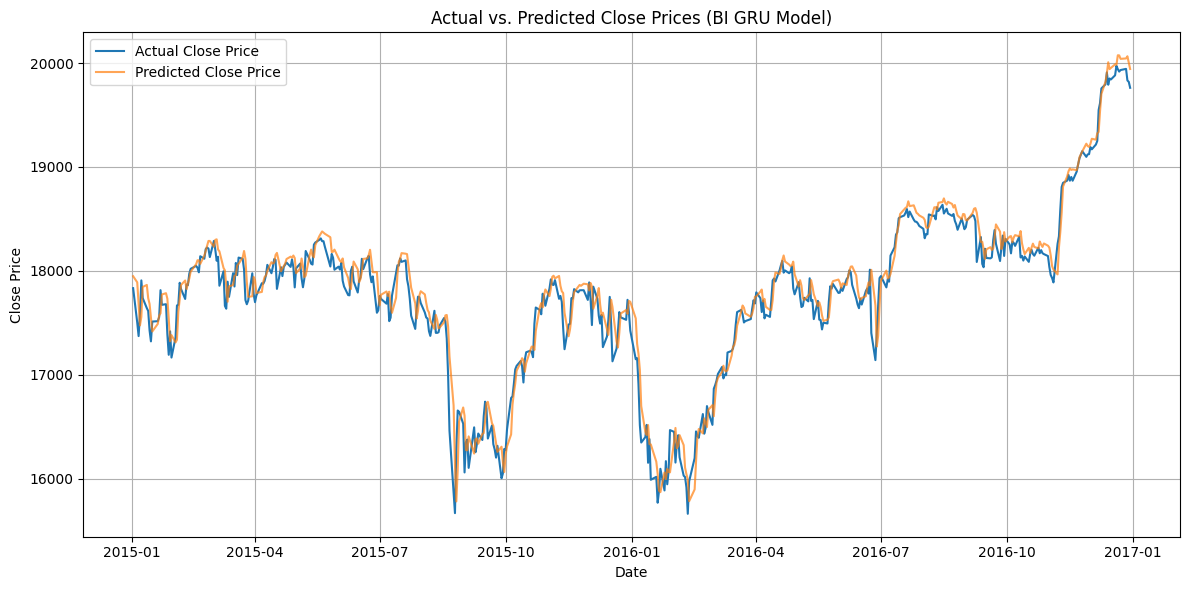

In [86]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_actual, label='Actual Close Price')
plt.plot(dates_test, y_pred2, label='Predicted Close Price', alpha=0.7)
plt.title('Actual vs. Predicted Close Prices (BI GRU Model)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

DEEP

In [56]:

model_deep = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Use X_train.shape[2] for features
    GRU(128, return_sequences=True,),

    GRU(128, return_sequences=False),

    Dense(32, activation='relu'),
    Dense(1)
], name='GRU')

model_deep.compile(optimizer='adam', loss='mean_squared_error')


model_deep.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 1, 128)         │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,921 (601.25 KB)

 Trainable params: 153,921 (601.25 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:


history_deep = model_deep.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0339 - val_loss: 0.0121
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.7550e-04 - val_loss: 3.6342e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3200e-04 - val_loss: 2.4375e-04
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2685e-04 - val_loss: 1.7508e-04
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3180e-04 - val_loss: 1.7031e-04
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2435e-04 - val_loss: 1.8521e-04
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2224e-04 - val_loss: 2.5289e-04
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2644e-04 - val_loss: 1.6236e-04
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2395e-04 - val_loss: 2.2097e-04
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2347e-04 - val_loss: 1.5687e-04
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2994e-04 - val_loss: 1.55

In [78]:
y_pred_scaled3 = model_deep.predict(X_test, verbose=0)

def inverse_close(scaled_col, scaler, n_features=4, close_idx=3):
    dummy = np.zeros((len(scaled_col), n_features))
    dummy[:, close_idx] = scaled_col.ravel()
    return scaler.inverse_transform(dummy)[:, close_idx]


In [79]:
y_pred3 = inverse_close(y_pred_scaled3, scaler, n_features=len(FEATURES), close_idx=TARGET_COL)
y_test_actual = inverse_close(y_test,        scaler, n_features=len(FEATURES), close_idx=TARGET_COL)


In [80]:
print(f"Test samples   : {len(y_test_actual)}")
print(f"Actual  range  : ${y_test_actual.min():,.2f}  –  ${y_test_actual.max():,.2f}")
print(f"Pred    range  : ${y_pred3.min():,.2f}  –  ${y_pred3.max():,.2f}")

Test samples   : 504
Actual  range  : $15,660.18  –  $19,974.62
Pred    range  : $15,739.94  –  $20,049.93


In [99]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred3))
r2   = 1 - (np.sum((y_test_actual - y_pred3)**2) /
            np.sum((y_test_actual - np.mean(y_test_actual))**2))

print("═" * 40)
print(f"  RMSE  : {rmse}  (USD points)")
print(f"  R²    : {r2}")
print("═" * 40)

════════════════════════════════════════
  RMSE  : 165.05574331520845  (USD points)
  R²    : 0.9563939347748109
════════════════════════════════════════


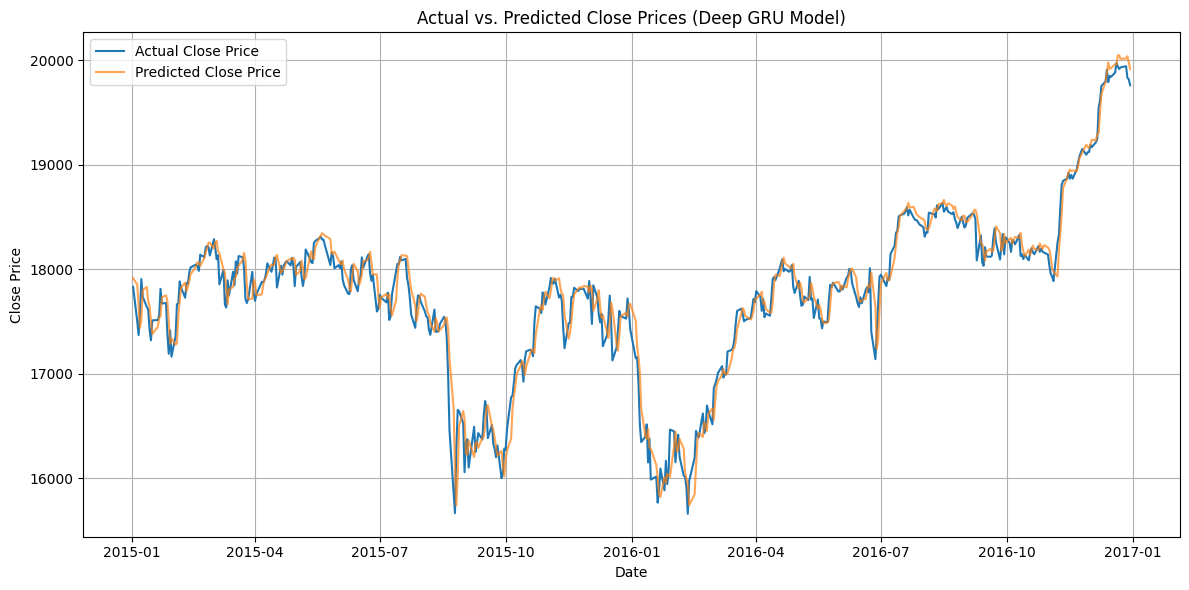

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_actual, label='Actual Close Price')
plt.plot(dates_test, y_pred3, label='Predicted Close Price', alpha=0.7)
plt.title('Actual vs. Predicted Close Prices (Deep GRU Model)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##check the result

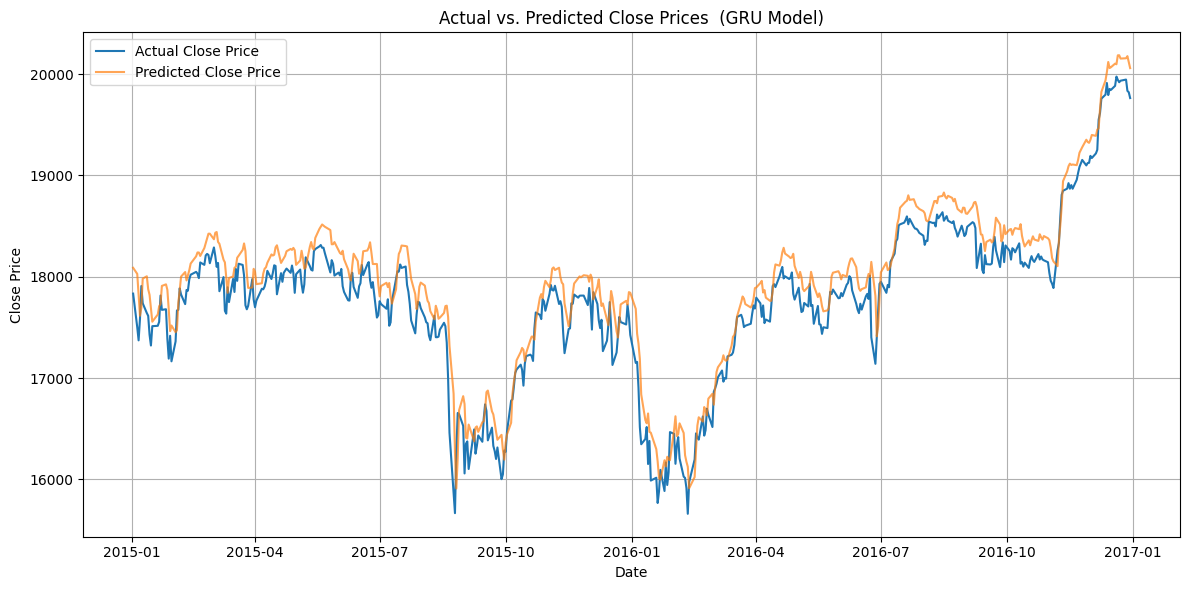

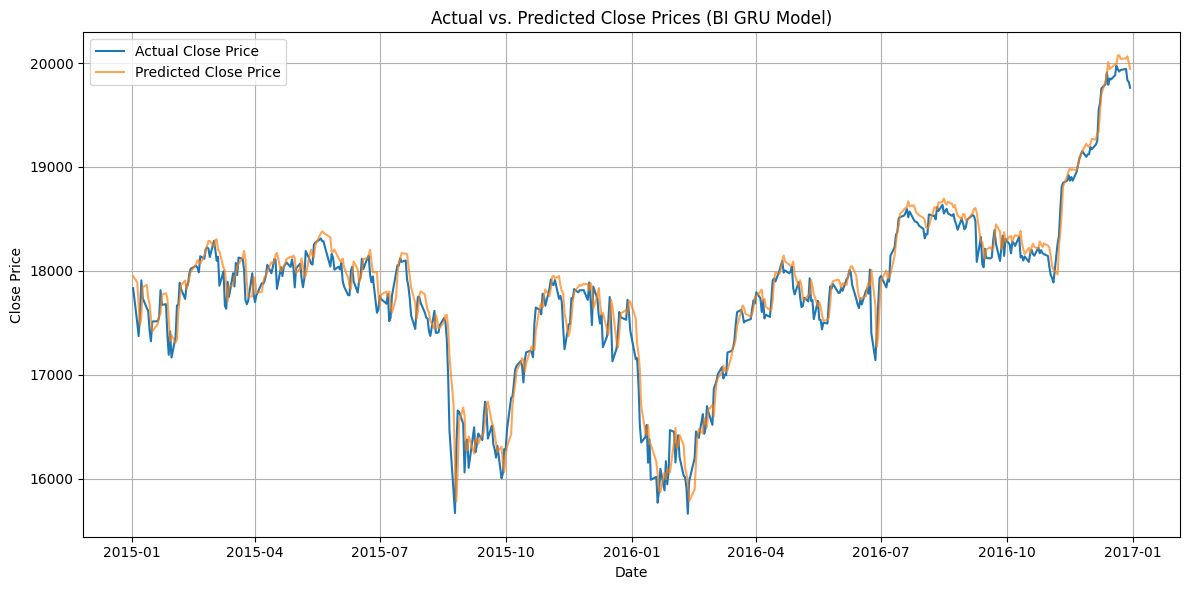

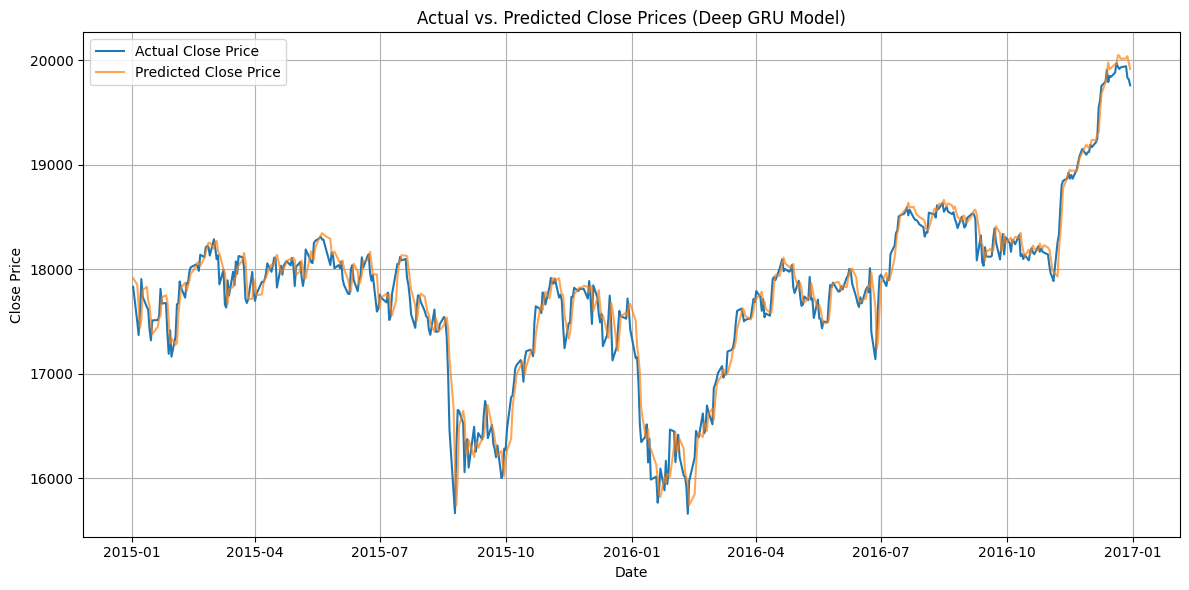